# GTra pipeline — step-by-step test

Validates the **edited** `gtra` source (C cleanup + A1/A2/B1/B2 fixes + matplotlib PdfPages import) end-to-end on the MND dataset, mirroring `tutorials/Tutorial.ipynb`.

Run top-to-bottom with the **`Python (gtra_test)`** kernel. Each section has a sanity check; the A2 and B2 fixes have explicit regression cells.

- **A2** regression: an extra `batch` column is injected into `obs` — the old `_score_distribution` mis-mapped / KeyError'd whenever obs had more than `[cell_type, cluster_label]`.
- **B2** regression: `module_evaluation()` is exercised both via the in-memory `pattern_key_map` and via the CSV fallback.

## Step 0 — environment check (must import the editable source)

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

import gtra

print('gtra.__file__ :', gtra.__file__)
assert 'submission/NatureCom/GTra/src/gtra' in gtra.__file__, \
    'NOT the edited source! From the GTra root run:  pip install -e .'
print('OK — using the edited (editable-installed) source')

gtra.__file__ : /data1/home/jyj/PROJECT/2025/submission/NatureCom/GTra/src/gtra/__init__.py
OK — using the edited (editable-installed) source


## Step 1 — load MND data (HVG-subset, 2000 genes, 4 timepoints)

In [2]:
DATA = Path('/data3/projects/2025_GTRA/data/1_MND')
adata = sc.read_h5ad(DATA / 'CCTSD_preproc_hvg.h5ad')   # already HVG-subset
print('shape:', adata.shape)
print('timepoints:', sorted(adata.obs['timepoints'].unique()))
print('cell_type2 :', adata.obs['cell_type2'].nunique(), 'types')
print('layers     :', list(adata.layers.keys()))

shape: (6316, 2000)
timepoints: [11, 13, 15, 17]
cell_type2 : 7 types
layers     : ['counts']


## Step 2 — build object, upload time points, `select_genes`

An extra `batch` column is added to `obs` on purpose — this is the **A2 regression**: with >2 obs columns the old mapping broke.

In [3]:
obj = gtra.GTraObject()
obj.params.cell_type_label = 'cell_type2'
obj.params.output_dir = './test_out'
obj.params.output_name = 'MND_test'

rng = np.random.default_rng(0)
for time in sorted(adata.obs['timepoints'].unique()):
    dat = adata[adata.obs['timepoints'] == time]
    cnt = dat.to_df(layer='counts')
    meta = dat.obs[[obj.params.cell_type_label]].copy()
    meta['batch'] = rng.integers(0, 3, size=meta.shape[0]).astype(str)   # A2 regression: extra obs column
    obj.upload_time_scRNA(cnt, meta)

obj.select_genes()
print('tp_data_num:', obj.tp_data_num, '| genes:', len(obj.genes))
print('obs columns (note extra "batch"):', list(obj.tp_data_dict[0].obs.columns))

tp_data_num: 4 | genes: 660
obs columns (note extra "batch"): ['cell_type2', 'batch']


## Step 3 — `find_gclusters` (Step 1: consensus gene clustering + edge stats)

This is where the **A2** code path (`_score_distribution`) runs. `N` is the bootstrap count.

In [4]:
obj.find_gclusters(N=50)   # bootstrap count (tutorial used 20). Smaller = faster but may yield few/degenerate modules.
print('cell_optimal_k per tp:', obj.cell_optimal_k)
print('ccmatrix timepoints  :', list(obj.ccmatrix.keys()))
print('dist_df rows:', len(obj.dist_df), '| pval_df rows:', len(obj.pval_df))
obj.dist_df.head()

Step 1: Identifying cell type-specific gene clusters...
cell_optimal_k per tp: {0: 7, 1: 7, 2: 7, 3: 6}
ccmatrix timepoints  : [0, 1, 2, 3]
dist_df rows: 5182 | pval_df rows: 138


,Interval,source,target,score
0,0,1-Neurons,1-Neurons,2.50
1,0,1-Neurons,1-Neurons,1.45
2,0,1-Neurons,1-Neurons,1.90
3,0,1-Neurons,1-Neurons,2.30
4,0,1-Neurons,1-Neurons,2.45


### A2 check — source/target are real `cell_type2` names despite the extra `batch` column

In [5]:
cts = set(adata.obs['cell_type2'].unique())
src_tgt = set(obj.dist_df['source']).union(obj.dist_df['target'])
print('dist_df source/target labels:', sorted(src_tgt))
assert src_tgt <= cts, f'A2 FAIL — non-celltype labels leaked: {src_tgt - cts}'
print('A2 OK — mapping is robust to the extra obs column')

dist_df source/target labels: ['1-Neurons', '2-Young neurons', '3-APs/RPs', '4-IPs', '5-APs/RPs', '6-Young neurons', '7-IPs']
A2 OK — mapping is robust to the extra obs column


## Step 4 — `construct_trajectories` (Step 2: candidate edges + paths)

In [6]:
obj.construct_trajectories()
print('node_info edges:', len(obj.node_info))
print('candidate paths:', len(obj.net_info))
obj.node_info.head()

Step 2: Constructing cell-state trajectories..: 100%|=================| 3/3 [00:13<00:00,  4.64s/it]

node_info edges: 77
candidate paths: 100


,from,to,sim,cos,rank_val
0,t0_0_1,t1_1_0,0.363636,0.194883,2.35
1,t0_0_0,t1_0_2,0.306306,0.090880,2.50
2,t0_0_1,t1_0_0,0.315789,0.225197,4.10
3,t0_0_0,t1_0_1,0.321256,0.227633,4.15
4,t0_0_2,t1_0_2,0.289412,0.198211,4.50


## Step 5 — `pattern_clustering` (Step 3: time-series pattern modules)

In [7]:
obj.pattern_clustering()
print('merge_pattern_dict modules:', len(obj.merge_pattern_dict))

Step 3: Detecting time-series pattern clustering...: 100%|==========| 43/43 [00:01<00:00, 33.92it/s]


merge_pattern_dict modules: 42


## Step 6 — visualizations

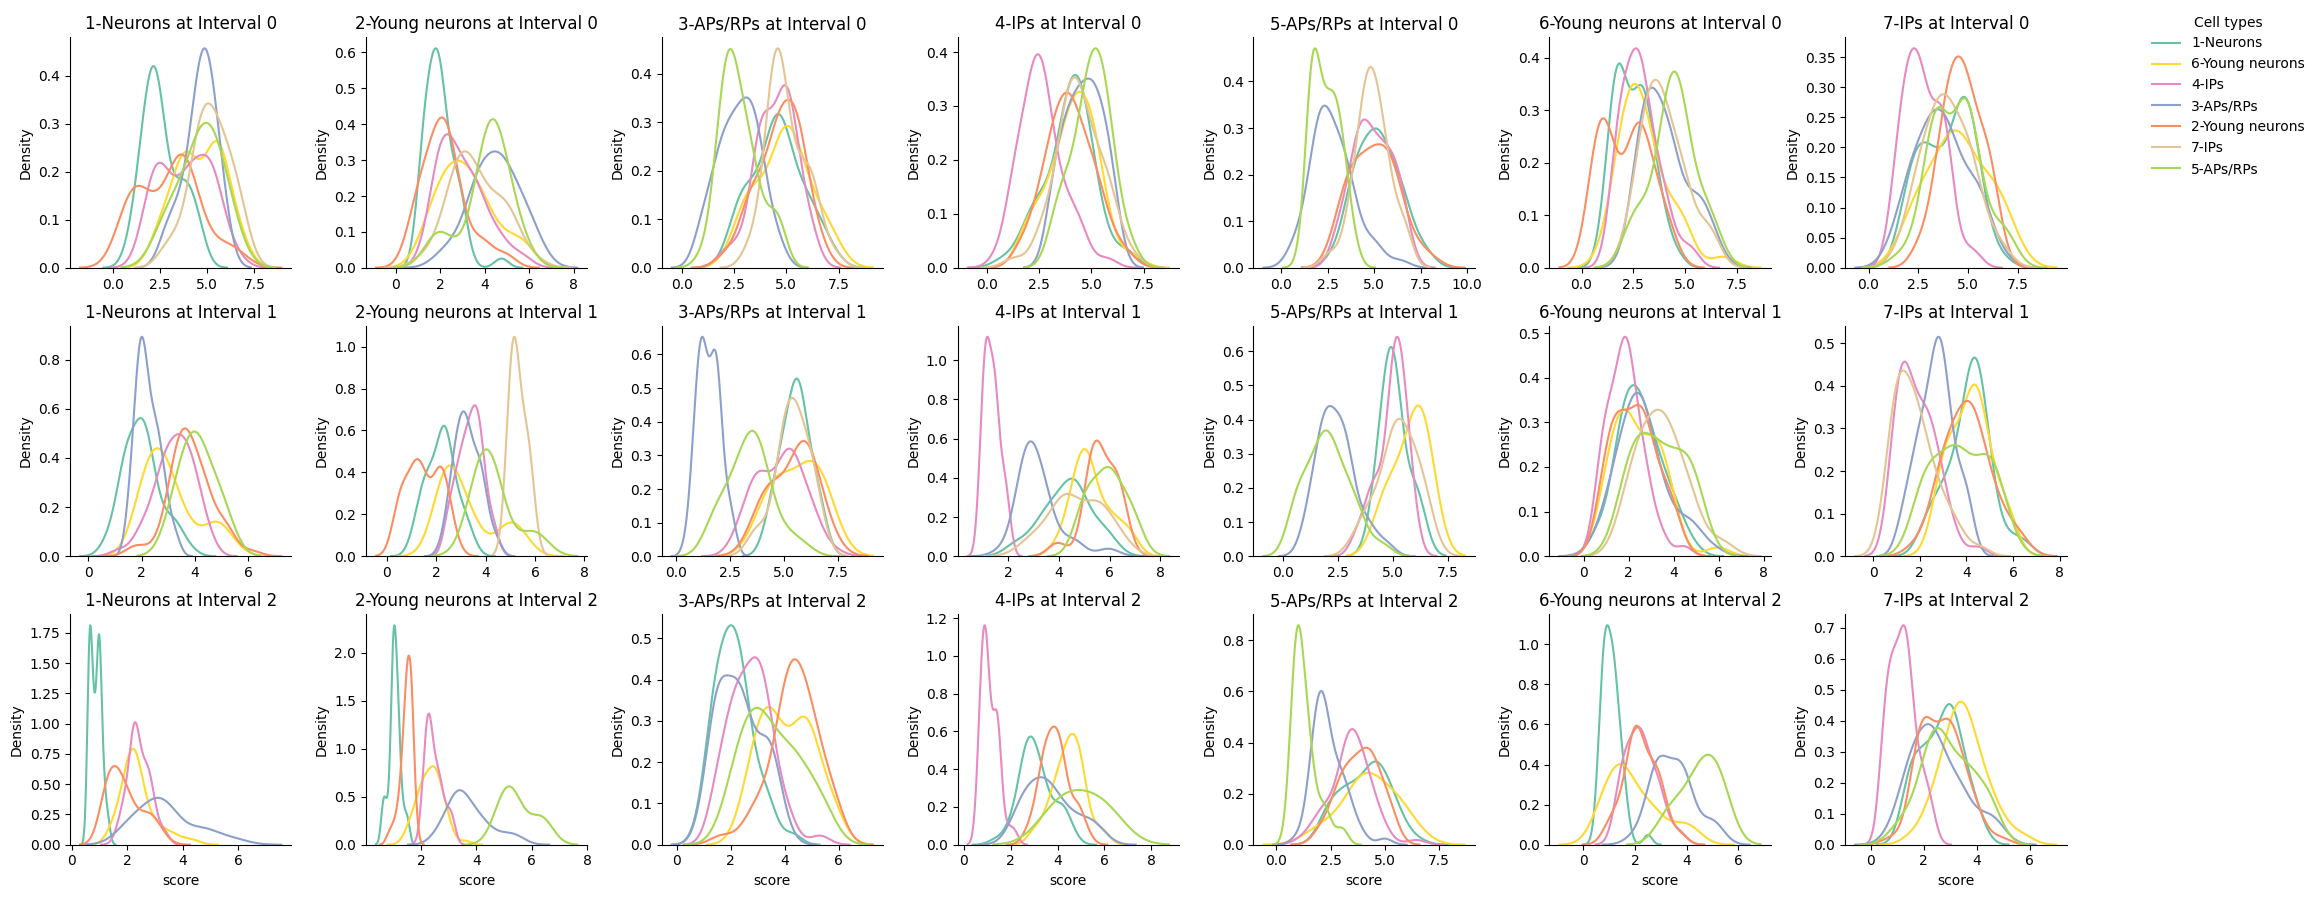

In [8]:
obj.plot_edge_statistic()

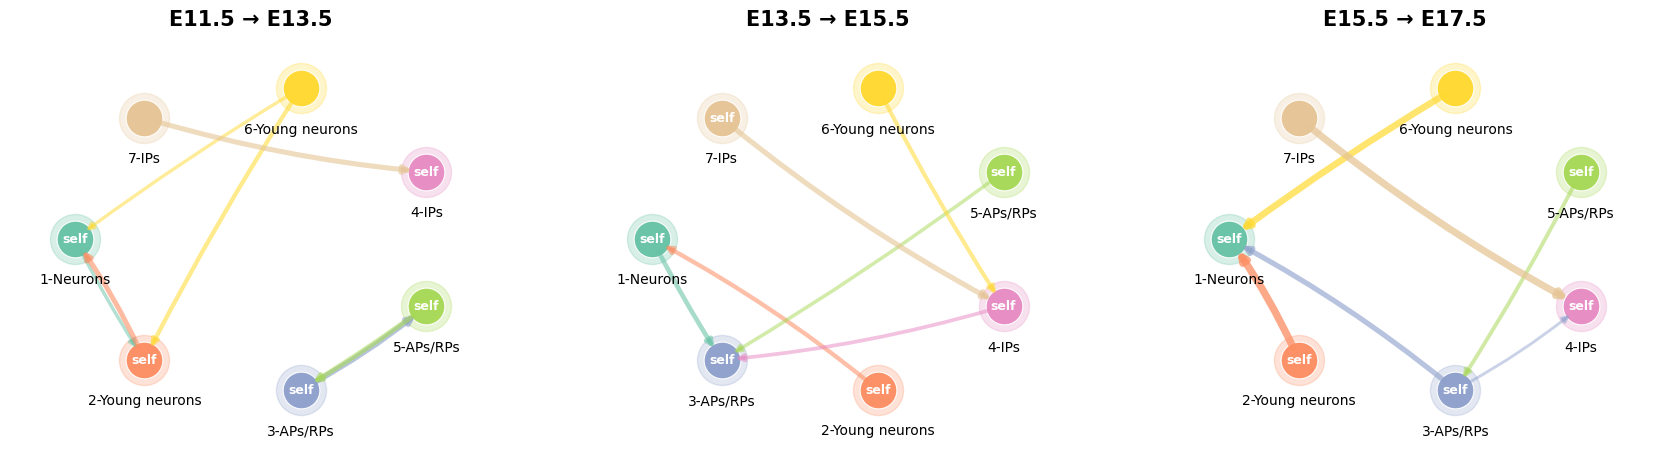

In [9]:
obj.params.time_point_label = ['E11.5', 'E13.5', 'E15.5', 'E17.5']
obj.plot_cell_state_graph()

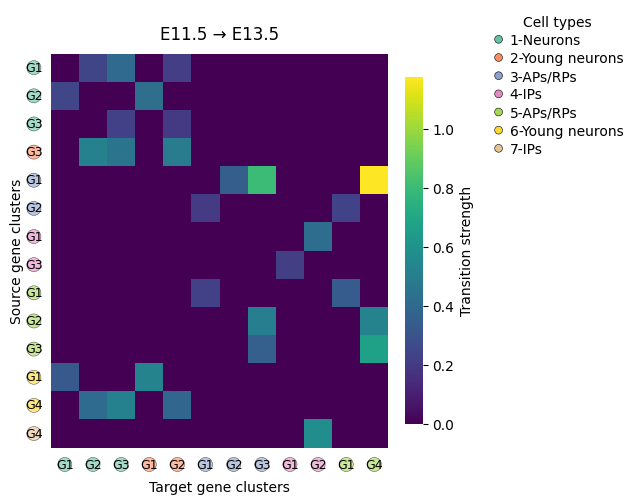

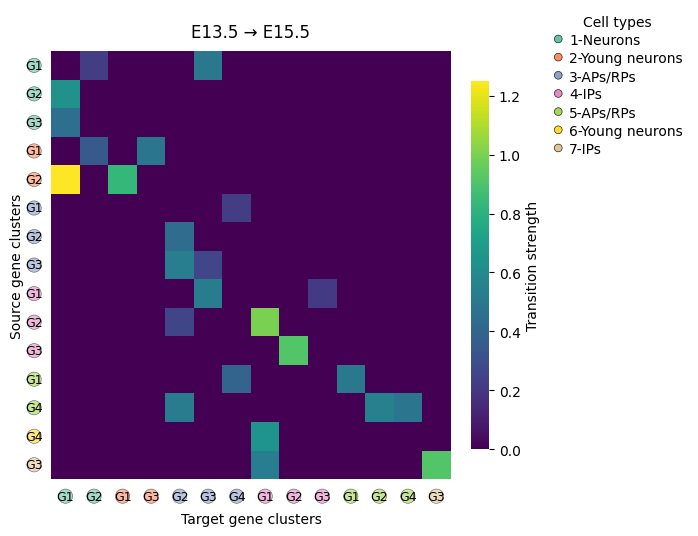

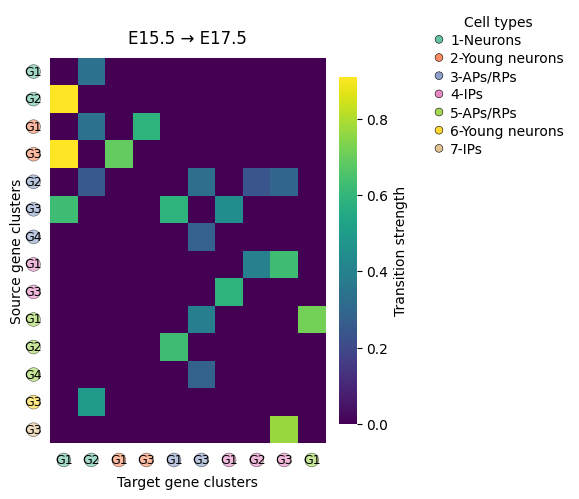

In [10]:
obj.plot_gg_matrix()

Plotting time-series gene expression patterns...


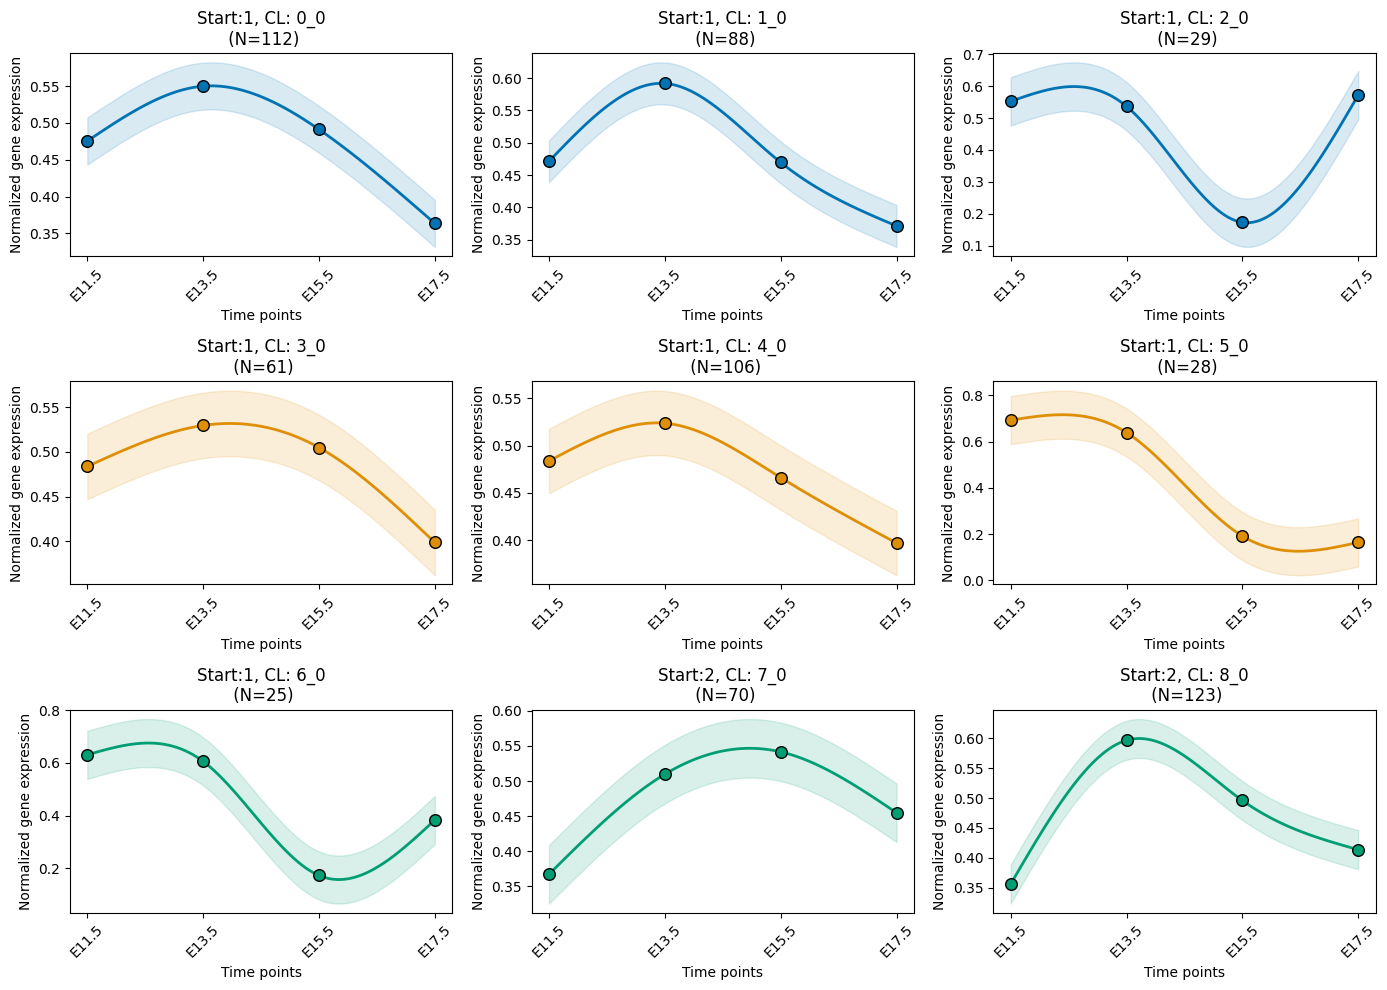

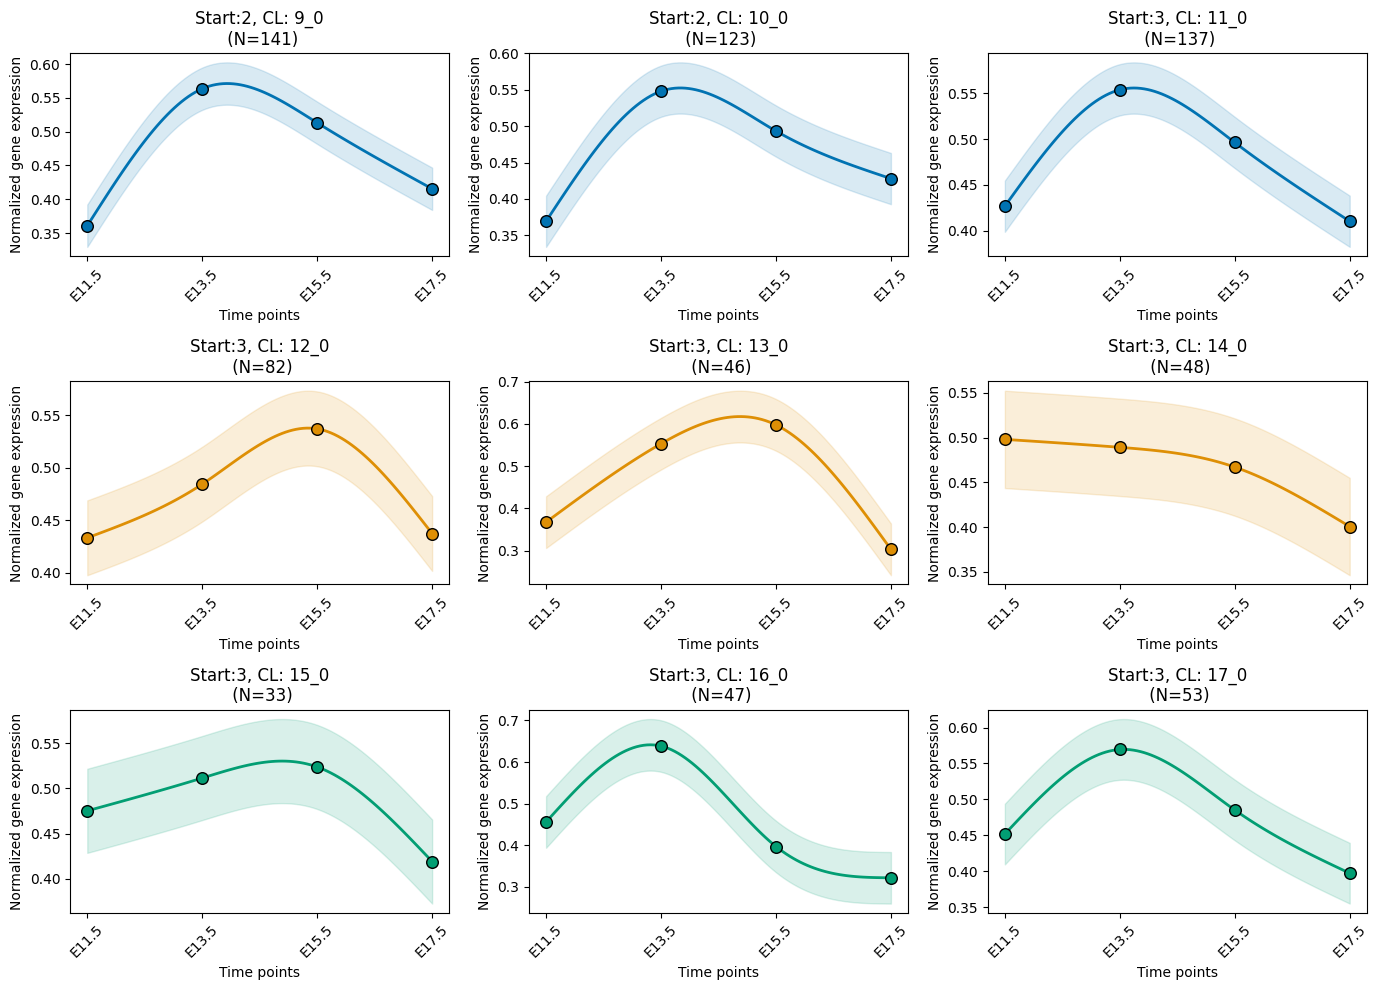

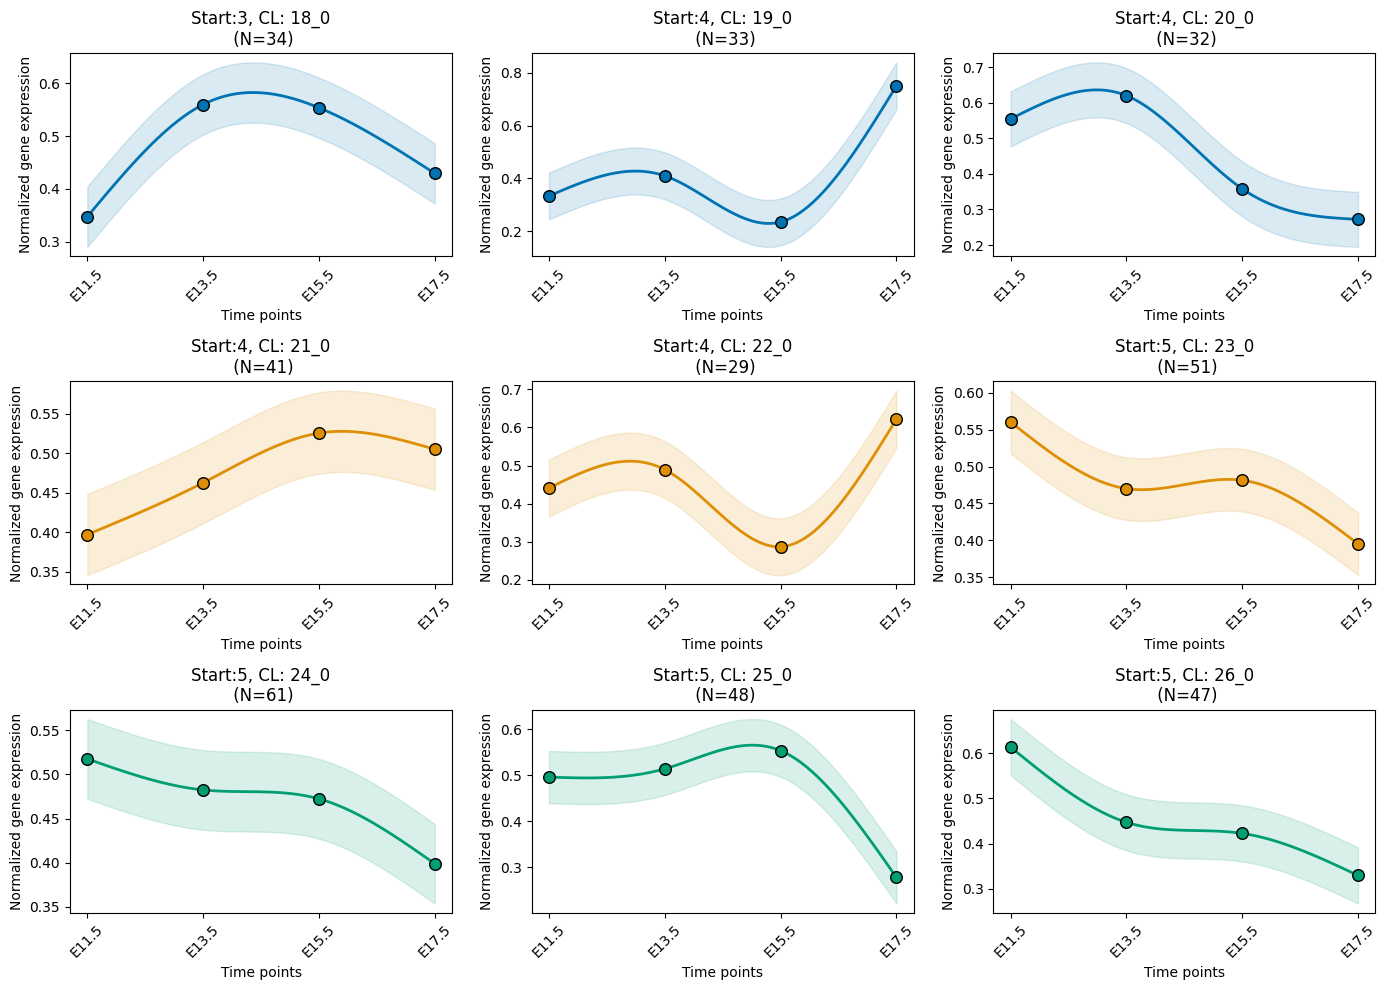

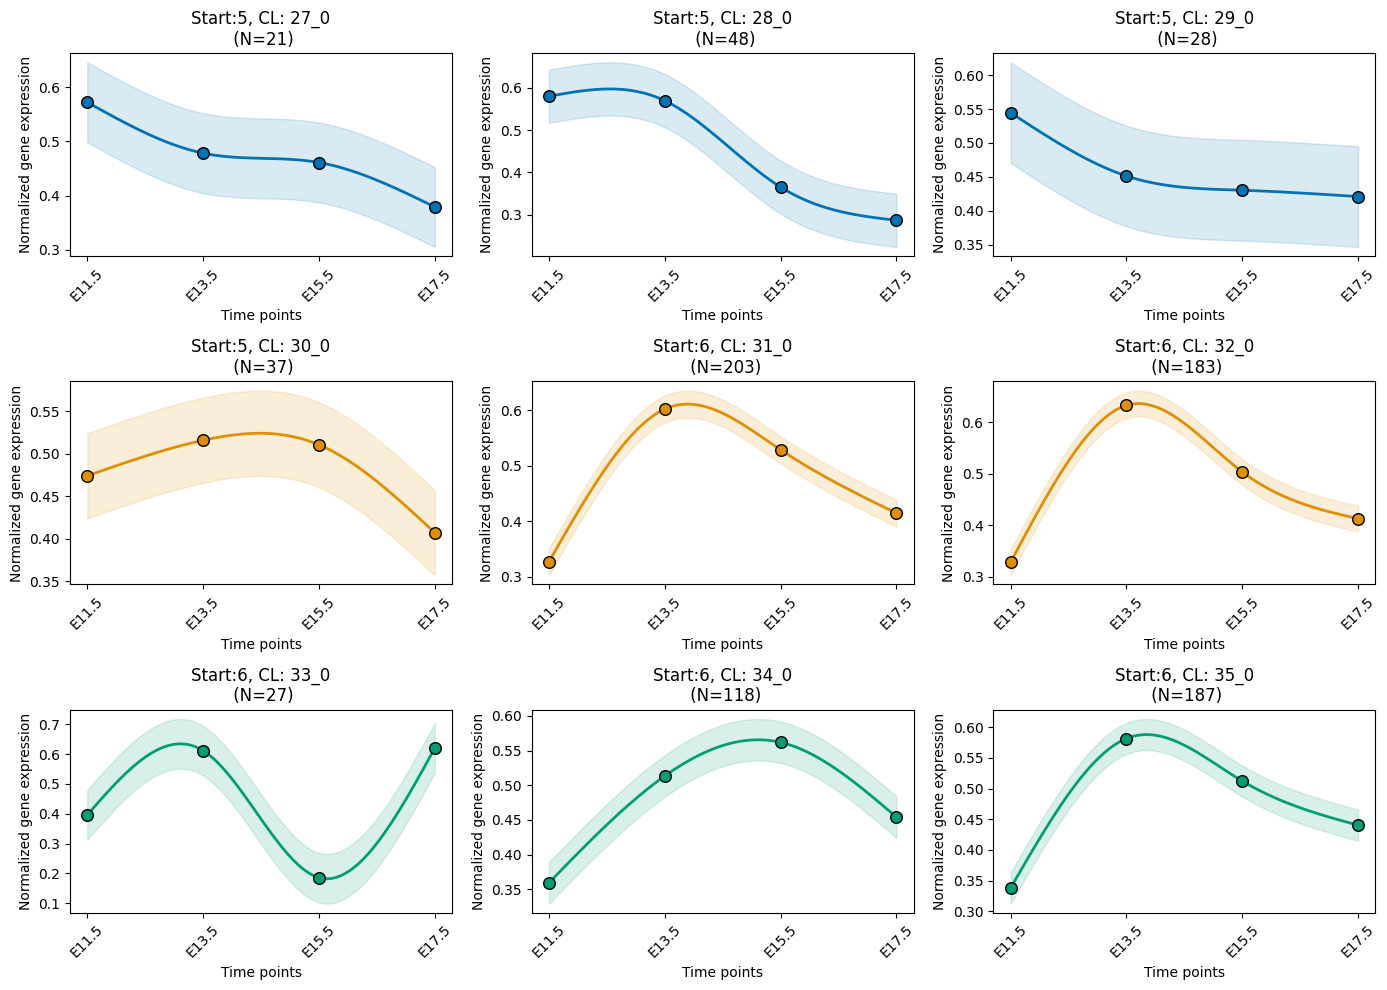

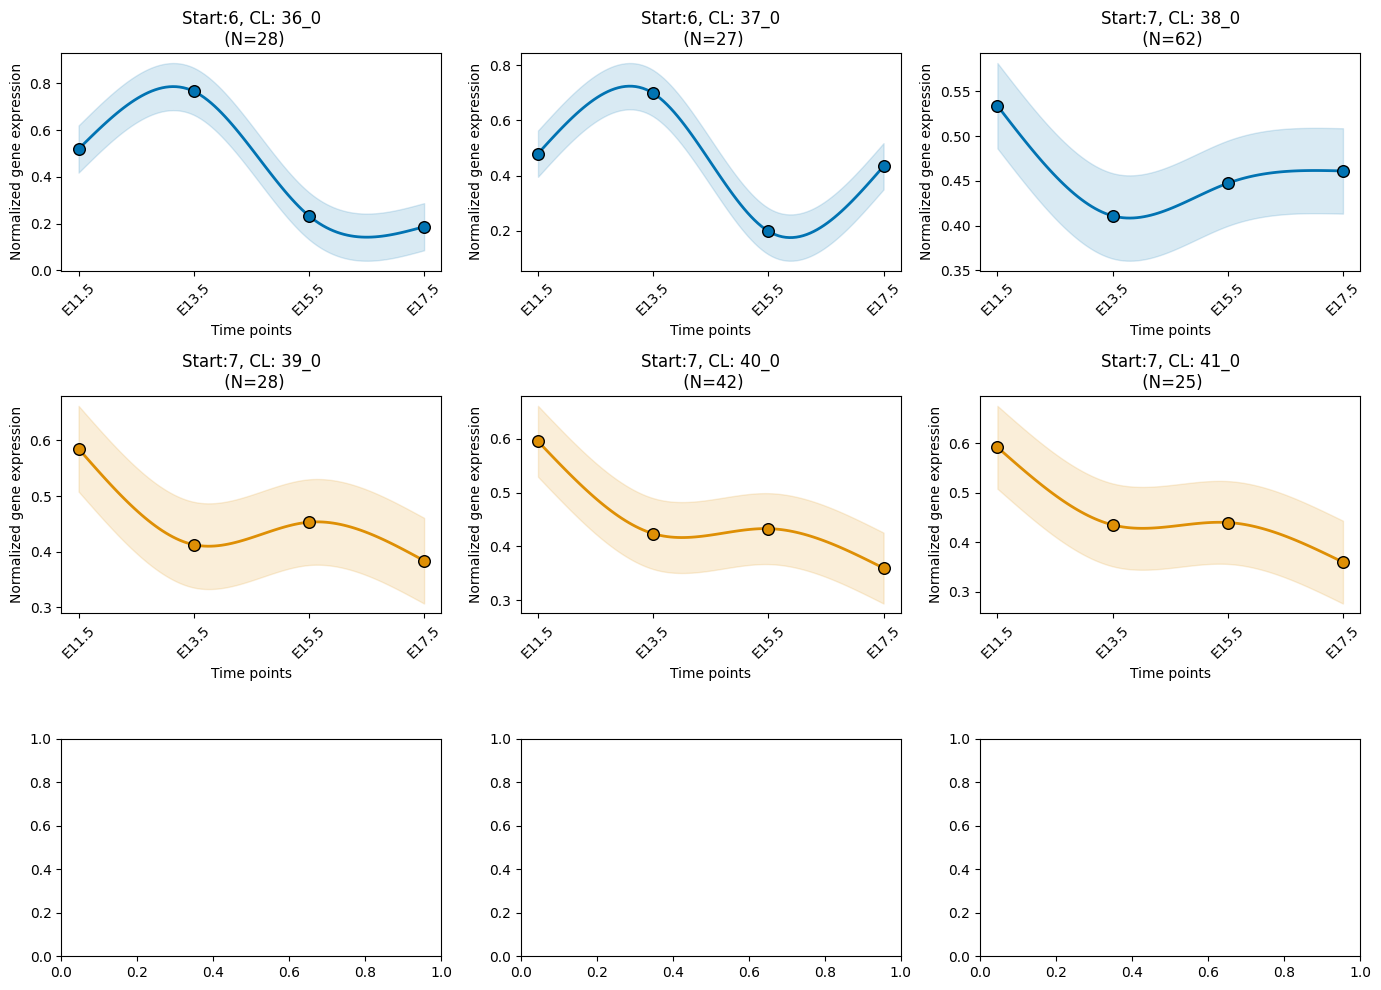

B2 — pattern_key_map populated: True | n = 42


In [11]:
# writes test_out/MND_test_pattern_genes.csv AND sets obj.pattern_key_map (B2)
obj.plot_patterns()
print('B2 — pattern_key_map populated:', hasattr(obj, 'pattern_key_map'),
      '| n =', len(getattr(obj, 'pattern_key_map', {})))

## Step 7 — `module_evaluation` (B2: in-memory path **and** CSV fallback)

In [12]:
# (a) in-memory path — uses obj.pattern_key_map set by plot_patterns()
obj.module_evaluation()
print('in-memory  -> sig_patterns:', len(obj.sig_patterns), '| module_df:', len(obj.module_df))

# (b) CSV-fallback path — drop the in-memory map, must still work from the CSV
saved = obj.pattern_key_map
del obj.pattern_key_map
obj.module_evaluation()
print('csv-fallback -> sig_patterns:', len(obj.sig_patterns))
obj.pattern_key_map = saved
print('B2 OK — both paths produced a result')

in-memory  -> sig_patterns: 34 | module_df: 34
csv-fallback -> sig_patterns: 34
B2 OK — both paths produced a result


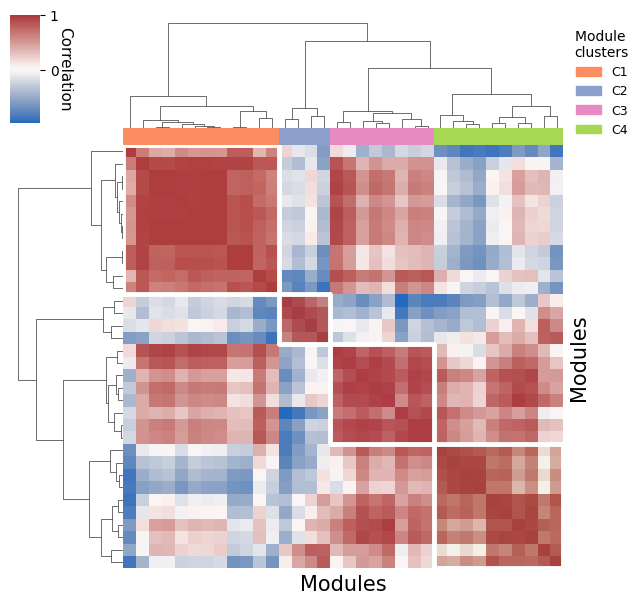

In [13]:
obj.plot_module_cluster()

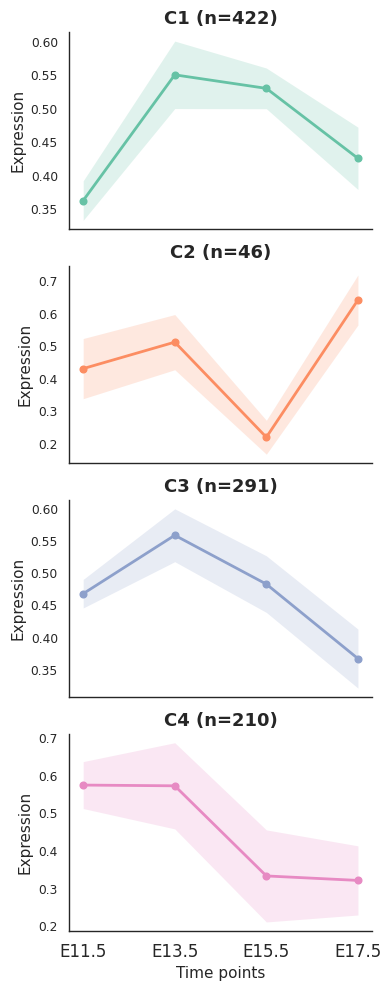

In [14]:
obj.plot_rep_patterns()

In [15]:
# Sankey trajectory (needs kaleido for the PDF export; inline figure shown regardless)
obj.plot_trajectory()

In [22]:
obj.pval_df.head(10)

,Interval,source,target,p-value,adj_p-value
0,0,1-Neurons,1-Neurons,1.505943e-09,1.054160e-08
1,0,1-Neurons,2-Young neurons,3.408465e-04,1.192963e-03
2,0,1-Neurons,3-APs/RPs,9.914651e-01,9.999952e-01
3,0,1-Neurons,4-IPs,7.974431e-01,9.999952e-01
4,0,1-Neurons,5-APs/RPs,9.438268e-01,9.999952e-01
5,0,1-Neurons,6-Young neurons,9.999741e-01,9.999952e-01
6,0,1-Neurons,7-IPs,9.999952e-01,9.999952e-01
7,0,2-Young neurons,1-Neurons,3.430256e-10,2.401179e-09
8,0,2-Young neurons,2-Young neurons,3.535345e-06,1.237371e-05
9,0,2-Young neurons,3-APs/RPs,9.999999e-01,9.999999e-01


## Step 8 — Trajectory accuracy (transition edge-F1 vs answer graph)

Builds the predicted **cell-type transition graph** from `obj.node_info` (`ged_utils.state_graph`) and scores it against the MND answer graph. Valid only because this run is **answer-unconstrained** (`answer_path_dir=""`).

In [23]:
import sys
sys.path.insert(0, '../case_study/MND')
import ged_utils as g

ANSWER = '/data3/projects/2025_GTRA/data/1_MND/cctsd_answer.csv'
G_pred = g.state_graph(obj, annot_col='cell_type2')      # node_info -> cell-type transition graph
G_ref  = g.answer_graph(ANSWER)

overall = g.edge_prf(G_pred, G_ref)                        # incl. self-loops
trans   = g.edge_prf(G_pred, G_ref, ignore_selfloops=True) # transition-only (off-diagonal)
rand    = g.random_transition_f1(G_pred, G_ref, n=500)     # random-relabel baseline

print('overall    :', overall)
print('transition :', trans)
print(f'transition F1 {trans["f1"]:.3f}  vs random {rand:.3f}  ({trans["f1"]/rand:.1f}x)')

overall    : {'precision': 0.7777777777777778, 'recall': 0.56, 'f1': 0.6511627906976745, 'n_pred': 18, 'n_ref': 25, 'n_correct': 14}
transition : {'precision': 0.6666666666666666, 'recall': 0.4444444444444444, 'f1': 0.5333333333333333, 'n_pred': 12, 'n_ref': 18, 'n_correct': 8}
transition F1 0.533  vs random 0.345  (1.5x)


## Done

If every cell ran without error and the **A2 OK** / **B2 OK** checks passed, the edited source works end-to-end. Outputs are under `./test_out/`.